# Módulo 1 — Generación del dataset sintético RutaViva

**Proyecto:** Sistema Inteligente Integrado para RutaViva
**Curso:** Redes Neuronales Artificiales
**Notebook:** `00_generacion_dataset.ipynb`

---

## Objetivo

Generar un dataset sintético realista de la demanda diaria de pasajeros para 6 rutas operadas por RutaViva, cubriendo 2 años completos (2023–2024). Este dataset servirá de base para el módulo de predicción de series temporales (LSTM).

## ¿Por qué un dataset sintético?

El recurso citado en el enunciado (artículo de GeeksforGeeks) genera también un dataset sintético, pero con valores puramente aleatorios (`np.random.choice` uniforme), **sin estacionalidad ni tendencia**. Un modelo LSTM no podría aprender nada útil sobre esos datos.

En cambio, nuestro dataset incorpora **patrones explícitos** que reflejan el comportamiento real de una empresa de transporte colombiana:

1. **Nivel de base diferenciado por ruta** (las rutas turísticas largas tienen menos demanda diaria que las rutas regionales cortas).
2. **Tendencia lineal positiva** (crecimiento orgánico de RutaViva del ~5% anual).
3. **Estacionalidad semanal** (picos viernes y domingo, valles martes y miércoles).
4. **Estacionalidad anual** (temporada alta diciembre–enero, Semana Santa, vacaciones de mitad de año).
5. **Festivos colombianos** (incremento de demanda en puentes festivos, muy típicos en Colombia).
6. **Ruido gaussiano** moderado para imitar la variabilidad real.

Este enfoque está inspirado en el modelo aditivo/multiplicativo clásico de series temporales (similar al modelo Prophet de Meta).

## Limitaciones reconocidas

- Los datos son **sintéticos**, no reales. Esta limitación se discute en la sección de aspectos éticos del reporte.
- Los patrones inyectados son simplificados respecto a la realidad operativa de una empresa de transporte.


## 0. Conexión a Google Drive

Este notebook guarda sus salidas (el CSV generado) directamente en Google Drive, en la carpeta `proyecto3-rutaviva/data/`. Asegúrate de haber creado esa carpeta antes de ejecutar.

Estructura esperada en Drive:
```
proyecto3-rutaviva/
├── data/        ← aquí se guardará rutaviva_demanda.csv
├── models/
└── figures/
```


In [1]:
# Montaje de Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Carpeta raíz del proyecto en Drive
DRIVE = '/content/drive/MyDrive/proyecto3-rutaviva'

# Verificación de que la estructura existe
import os
for subdir in ['data', 'models', 'figures']:
    ruta = f'{DRIVE}/{subdir}'
    if not os.path.exists(ruta):
        raise FileNotFoundError(
            f'No encuentro {ruta}. Créala manualmente en tu Drive antes de continuar.'
        )

print(f'Drive montado. Proyecto en: {DRIVE}')

Mounted at /content/drive
Drive montado. Proyecto en: /content/drive/MyDrive/proyecto3-rutaviva


## 1. Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

# Reproducibilidad: misma semilla = mismo dataset cada vez que se ejecuta
SEMILLA = 42
np.random.seed(SEMILLA)

print("Librerías cargadas. Semilla fijada en", SEMILLA)

Librerías cargadas. Semilla fijada en 42


## 2. Parámetros generales del dataset

Definimos aquí todos los parámetros que controlan la generación. Centralizar estos parámetros facilita ajustar el dataset sin tocar el resto del código.

In [3]:
# --- Periodo cubierto ---
FECHA_INICIO = date(2023, 1, 1)
FECHA_FIN    = date(2024, 12, 31)

# Generamos el rango de fechas (731 días, 2 años completos)
fechas = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq='D')
print(f"Periodo: {FECHA_INICIO} → {FECHA_FIN}")
print(f"Número total de días: {len(fechas)}")

Periodo: 2023-01-01 → 2024-12-31
Número total de días: 731


## 3. Definición de las rutas RutaViva

Cada ruta tiene tres parámetros clave:

- **`base`** : nivel medio de pasajeros por día (sin estacionalidad ni ruido).
- **`peso_fin_de_semana`** : qué tan marcado es el pico del fin de semana (1.0 = sin pico, 1.8 = fuerte pico).
- **`peso_temporada_alta`** : qué tan marcada es la temporada alta de turismo (1.0 = sin efecto, 1.6 = fuerte efecto).

Estos pesos reflejan la naturaleza de cada ruta: las rutas turísticas cortas (Guatapé, Santa Fe) tienen un pico de fin de semana muy fuerte; las rutas largas turísticas (Cartagena) son muy sensibles a la temporada alta; las rutas inter-regionales (Bogotá) son más estables.

In [4]:
# Cada ruta es un diccionario con su perfil de demanda
RUTAS = {
    'Medellin-Pereira': {
        'base': 180,
        'peso_fin_de_semana': 1.35,
        'peso_temporada_alta': 1.20,
    },
    'Medellin-Manizales': {
        'base': 150,
        'peso_fin_de_semana': 1.35,
        'peso_temporada_alta': 1.20,
    },
    'Medellin-Bogota': {
        'base': 250,
        'peso_fin_de_semana': 1.45,
        'peso_temporada_alta': 1.15,
    },
    'Medellin-Cartagena': {
        'base': 120,
        'peso_fin_de_semana': 1.30,
        'peso_temporada_alta': 1.70,  # ruta turística larga: muy sensible a temporada alta
    },
    'Medellin-SantaFeAntioquia': {
        'base': 90,
        'peso_fin_de_semana': 1.80,   # ruta turística corta: pico de fin de semana muy fuerte
        'peso_temporada_alta': 1.25,
    },
    'Medellin-Guatape': {
        'base': 110,
        'peso_fin_de_semana': 1.85,   # ruta turística corta: pico de fin de semana muy fuerte
        'peso_temporada_alta': 1.30,
    },
}

# Mostramos las rutas configuradas
df_rutas = pd.DataFrame(RUTAS).T
df_rutas.index.name = 'ruta'
df_rutas

,base,peso_fin_de_semana,peso_temporada_alta
ruta,,,
Medellin-Pereira,180.0,1.35,1.20
Medellin-Manizales,150.0,1.35,1.20
Medellin-Bogota,250.0,1.45,1.15
Medellin-Cartagena,120.0,1.30,1.70
Medellin-SantaFeAntioquia,90.0,1.80,1.25
Medellin-Guatape,110.0,1.85,1.30


## 4. Festivos colombianos 2023–2024

Colombia tiene muchos festivos que generan los famosos **"puentes festivos"** (cuando un festivo cae lunes o se traslada al lunes, creando un fin de semana de 3 días). Estos puentes son momentos de alta demanda de transporte regional.

Listamos manualmente los festivos para 2023 y 2024. La columna `tipo` distinguirá:
- `puente` : festivo que genera un puente largo (mayor impacto).
- `simple` : festivo aislado entre semana (impacto menor).

In [5]:
# Festivos colombianos 2023 + 2024 (fechas oficiales)
# Fuente: calendario oficial de Colombia
FESTIVOS_RAW = [
    # 2023
    ('2023-01-01', 'simple'),   # Año Nuevo
    ('2023-01-09', 'puente'),   # Reyes Magos (trasladado)
    ('2023-03-20', 'puente'),   # San José (trasladado)
    ('2023-04-06', 'simple'),   # Jueves Santo
    ('2023-04-07', 'simple'),   # Viernes Santo
    ('2023-05-01', 'simple'),   # Día del Trabajo
    ('2023-05-22', 'puente'),   # Ascensión (trasladado)
    ('2023-06-12', 'puente'),   # Corpus Christi (trasladado)
    ('2023-06-19', 'puente'),   # Sagrado Corazón (trasladado)
    ('2023-07-03', 'puente'),   # San Pedro y San Pablo (trasladado)
    ('2023-07-20', 'simple'),   # Día de la Independencia
    ('2023-08-07', 'simple'),   # Batalla de Boyacá
    ('2023-08-21', 'puente'),   # Asunción (trasladado)
    ('2023-10-16', 'puente'),   # Día de la Raza (trasladado)
    ('2023-11-06', 'puente'),   # Todos los Santos (trasladado)
    ('2023-11-13', 'puente'),   # Independencia de Cartagena (trasladado)
    ('2023-12-08', 'simple'),   # Inmaculada Concepción
    ('2023-12-25', 'simple'),   # Navidad
    # 2024
    ('2024-01-01', 'simple'),
    ('2024-01-08', 'puente'),
    ('2024-03-25', 'puente'),
    ('2024-03-28', 'simple'),
    ('2024-03-29', 'simple'),
    ('2024-05-01', 'simple'),
    ('2024-05-13', 'puente'),
    ('2024-06-03', 'puente'),
    ('2024-06-10', 'puente'),
    ('2024-07-01', 'puente'),
    ('2024-07-20', 'simple'),
    ('2024-08-07', 'simple'),
    ('2024-08-19', 'puente'),
    ('2024-10-14', 'puente'),
    ('2024-11-04', 'puente'),
    ('2024-11-11', 'puente'),
    ('2024-12-08', 'simple'),
    ('2024-12-25', 'simple'),
]

festivos = pd.DataFrame(FESTIVOS_RAW, columns=['fecha', 'tipo'])
festivos['fecha'] = pd.to_datetime(festivos['fecha'])
print(f"Festivos cargados: {len(festivos)} ({(festivos['tipo']=='puente').sum()} puentes, {(festivos['tipo']=='simple').sum()} simples)")
festivos.head()

Festivos cargados: 36 (20 puentes, 16 simples)


,fecha,tipo
0,2023-01-01,simple
1,2023-01-09,puente
2,2023-03-20,puente
3,2023-04-06,simple
4,2023-04-07,simple


## 5. Funciones de los componentes de la serie

Construimos el dataset multiplicando 5 componentes (más un ruido aditivo). Cada componente está implementado en una función separada para mayor legibilidad.

### 5.1 Tendencia lineal

Crecimiento orgánico de RutaViva del ~5% anual. Modelado como multiplicador que arranca en 1.0 al inicio del periodo y llega a 1.10 al cabo de 2 años.

In [6]:
def factor_tendencia(fecha, fecha_inicio=FECHA_INICIO, crecimiento_anual=0.05):
    """Multiplicador de tendencia lineal.

    Arranca en 1.0 el día `fecha_inicio` y crece linealmente con el tiempo.
    """
    dias_transcurridos = (fecha.date() - fecha_inicio).days
    return 1.0 + crecimiento_anual * (dias_transcurridos / 365.0)


# Test rápido
print(f"Tendencia al inicio (2023-01-01): {factor_tendencia(pd.Timestamp('2023-01-01')):.3f}")
print(f"Tendencia al medio (2024-01-01):  {factor_tendencia(pd.Timestamp('2024-01-01')):.3f}")
print(f"Tendencia al final (2024-12-31):  {factor_tendencia(pd.Timestamp('2024-12-31')):.3f}")

Tendencia al inicio (2023-01-01): 1.000
Tendencia al medio (2024-01-01):  1.050
Tendencia al final (2024-12-31):  1.100


### 5.2 Estacionalidad semanal

Patrón típico de demanda de transporte regional en Colombia: pico el viernes y el domingo (regreso de fin de semana), valle entre martes y miércoles.

In [7]:
# Multiplicadores por día de la semana (0 = lunes, 6 = domingo)
PERFIL_SEMANAL = {
    0: 0.95,   # lunes
    1: 0.80,   # martes
    2: 0.80,   # miércoles
    3: 0.95,   # jueves
    4: 1.25,   # viernes (salidas)
    5: 1.05,   # sábado
    6: 1.30,   # domingo (regresos)
}


def factor_semanal(fecha, peso_fin_de_semana=1.0):
    """Multiplicador semanal modulado por el peso de fin de semana de la ruta.

    Si peso_fin_de_semana = 1.0, se aplica el perfil base.
    Si > 1.0, se amplifica el efecto fin de semana proporcionalmente.
    """
    base = PERFIL_SEMANAL[fecha.dayofweek]
    # Amplificación: el desvío de 1.0 se multiplica por el peso
    return 1.0 + (base - 1.0) * peso_fin_de_semana


# Test
for d in range(7):
    fecha_test = pd.Timestamp('2024-01-01') + pd.Timedelta(days=d)
    print(f"{fecha_test.day_name():10s} factor base: {factor_semanal(fecha_test):.2f}")

Monday     factor base: 0.95
Tuesday    factor base: 0.80
Wednesday  factor base: 0.80
Thursday   factor base: 0.95
Friday     factor base: 1.25
Saturday   factor base: 1.05
Sunday     factor base: 1.30


### 5.3 Estacionalidad anual

Modelamos la estacionalidad anual con una combinación de funciones sinusoidales que capturan:

- **Temporada alta de diciembre–enero** (fin de año, vacaciones escolares).
- **Semana Santa** (marzo–abril).
- **Vacaciones de mitad de año** (junio–julio).

Usamos el día del año (1–365) como variable. Esta forma sinusoidal es estándar en modelos de series temporales.

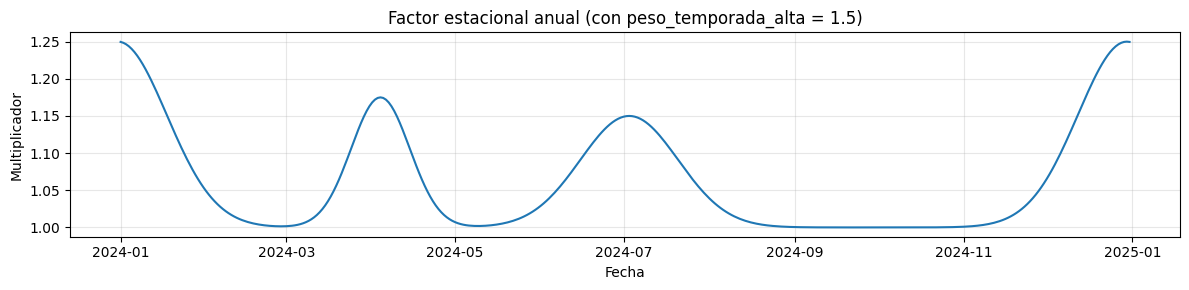

In [8]:
def factor_anual(fecha, peso_temporada_alta=1.0):
    """Multiplicador estacional anual.

    Combina varios pulsos centrados en las temporadas turísticas colombianas.
    """
    dia_del_año = fecha.dayofyear

    # Pulso 1: temporada alta de fin/inicio de año (dic-ene)
    # Centro en día 0 (1 enero), también activo a fin de año
    pulso_fin_año = np.exp(-((dia_del_año - 0) / 25.0) ** 2) +                     np.exp(-((dia_del_año - 365) / 25.0) ** 2)

    # Pulso 2: Semana Santa (alrededor del día 90, finales de marzo / inicio abril)
    pulso_semana_santa = np.exp(-((dia_del_año - 95) / 15.0) ** 2)

    # Pulso 3: vacaciones mitad de año (junio-julio, alrededor del día 180)
    pulso_mitad_año = np.exp(-((dia_del_año - 185) / 25.0) ** 2)

    # Combinación: suma de pulsos, modulada por el peso de la ruta
    intensidad = 0.5 * pulso_fin_año + 0.35 * pulso_semana_santa + 0.30 * pulso_mitad_año

    return 1.0 + intensidad * (peso_temporada_alta - 1.0)


# Visualización rápida del patrón anual
fechas_2024 = pd.date_range('2024-01-01', '2024-12-31', freq='D')
valores = [factor_anual(f, peso_temporada_alta=1.5) for f in fechas_2024]

plt.figure(figsize=(12, 3))
plt.plot(fechas_2024, valores)
plt.title('Factor estacional anual (con peso_temporada_alta = 1.5)')
plt.xlabel('Fecha')
plt.ylabel('Multiplicador')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Festivos colombianos

Por la **Ley Emiliani (1983)**, casi todos los festivos colombianos se trasladan al **lunes siguiente**, generando los famosos **puentes festivos** (fines de semana de 3 días). Esto estructura un patrón muy específico de demanda de transporte que nuestro modelo debe reflejar:

| Día relativo al puente | Comportamiento típico | Multiplicador |
|---|---|---|
| **Viernes (J-3)** | Los "puenteros" salen temprano para aprovechar los 3 días | **+30%** |
| **Sábado (J-2)** | Algunas salidas tardías | **+10%** |
| **Domingo (J-1)** | Demanda normal (la gente se queda hasta el lunes) | sin efecto |
| **Lunes festivo (J)** | Pico de regresos | **+25%** |
| **Martes (J+1)** | Regresos tardíos | **+5%** |

Para los **festivos simples** (los pocos que no se trasladan, como Navidad o Año Nuevo), aplicamos un **+15%** el día mismo.

> **Nota:** este patrón es uno de los puntos donde un modelo simple (como una media por día de la semana) fallaría: un domingo antes de puente *no* es un pico, mientras que un domingo normal sí lo es. Esta complejidad justifica el uso de un LSTM, capaz de aprender dependencias contextuales.


In [9]:
# Pre-calculamos un set de fechas festivas para acceso rápido
fechas_festivas_puente = set(festivos.loc[festivos['tipo']=='puente', 'fecha'].dt.date)
fechas_festivas_simple = set(festivos.loc[festivos['tipo']=='simple', 'fecha'].dt.date)


def factor_festivo(fecha):
    """Multiplicador asociado a los festivos colombianos.

    Por la Ley Emiliani (1983), la mayoría de los festivos colombianos se trasladan
    al lunes siguiente, generando los famosos "puentes festivos". Este patrón
    estructura el comportamiento de los viajeros de la siguiente manera:

    - Viernes (J-3): pico de salidas (los "puenteros" salen pronto)  → +30%
    - Sábado  (J-2): algunas salidas tardías                          → +10%
    - Domingo (J-1): demanda normal (la gente se queda hasta el lunes) → sin efecto
    - Lunes   (J)  : el festivo en sí, pico de regresos               → +25%
    - Martes  (J+1): regresos tardíos                                 → +5%

    Para los festivos simples (no trasladados), aplicamos un +15% el día mismo.
    """
    f = fecha.date()

    # 1. Festivo simple: efecto solo el día mismo
    if f in fechas_festivas_simple:
        return 1.15

    # 2. Lunes festivo (puente): pico de regresos
    if f in fechas_festivas_puente:
        return 1.25

    # 3. Días alrededor de un puente
    from datetime import timedelta
    # Viernes antes del puente (J-3)
    if (f + timedelta(days=3)) in fechas_festivas_puente:
        return 1.30
    # Sábado antes del puente (J-2)
    if (f + timedelta(days=2)) in fechas_festivas_puente:
        return 1.10
    # Martes después del puente (J+1)
    if (f - timedelta(days=1)) in fechas_festivas_puente:
        return 1.05

    return 1.0


# Test alrededor del puente del 8 de enero 2024 (lunes festivo)
print("Test alrededor del puente del 8 de enero 2024 (lunes festivo):")
for d in pd.date_range('2024-01-05', '2024-01-09'):
    print(f"  {d.date()} ({d.day_name():9s}) → factor festivo = {factor_festivo(d):.2f}")

print()
print("Test alrededor de un festivo simple (1 mayo 2024, miércoles):")
for d in pd.date_range('2024-04-29', '2024-05-03'):
    print(f"  {d.date()} ({d.day_name():9s}) → factor festivo = {factor_festivo(d):.2f}")


Test alrededor del puente del 8 de enero 2024 (lunes festivo):
  2024-01-05 (Friday   ) → factor festivo = 1.30
  2024-01-06 (Saturday ) → factor festivo = 1.10
  2024-01-07 (Sunday   ) → factor festivo = 1.00
  2024-01-08 (Monday   ) → factor festivo = 1.25
  2024-01-09 (Tuesday  ) → factor festivo = 1.05

Test alrededor de un festivo simple (1 mayo 2024, miércoles):
  2024-04-29 (Monday   ) → factor festivo = 1.00
  2024-04-30 (Tuesday  ) → factor festivo = 1.00
  2024-05-01 (Wednesday) → factor festivo = 1.15
  2024-05-02 (Thursday ) → factor festivo = 1.00
  2024-05-03 (Friday   ) → factor festivo = 1.00


## 6. Generación del dataset completo

Iteramos sobre cada combinación (fecha, ruta) y aplicamos la fórmula:

$$
\text{pasajeros}(t, r) = \text{base}(r) \times f_{\text{tend}}(t) \times f_{\text{sem}}(t, r) \times f_{\text{año}}(t, r) \times f_{\text{fest}}(t) + \varepsilon(t)
$$

donde $\varepsilon(t) \sim \mathcal{N}(0, \sigma^2)$ es un ruido gaussiano, y $\sigma$ se escala con el nivel base de cada ruta (10% del nivel base) para que el ruido sea proporcional al volumen.

In [10]:
filas = []

for nombre_ruta, params in RUTAS.items():
    base = params['base']
    peso_fds = params['peso_fin_de_semana']
    peso_ta  = params['peso_temporada_alta']
    sigma_ruido = base * 0.08  # 8% del nivel base

    for fecha in fechas:
        # Aplicación de los 4 multiplicadores
        f_tend = factor_tendencia(fecha)
        f_sem  = factor_semanal(fecha, peso_fin_de_semana=peso_fds)
        f_año  = factor_anual(fecha, peso_temporada_alta=peso_ta)
        f_fest = factor_festivo(fecha)

        # Componente determinista
        valor_det = base * f_tend * f_sem * f_año * f_fest

        # Ruido gaussiano
        ruido = np.random.normal(loc=0, scale=sigma_ruido)

        # Valor final: redondeado a entero, mínimo 0 (no puede haber pasajeros negativos)
        pasajeros = max(0, int(round(valor_det + ruido)))

        filas.append({
            'fecha': fecha,
            'ruta': nombre_ruta,
            'pasajeros': pasajeros,
        })

df = pd.DataFrame(filas)
print(f"Dataset generado: {len(df)} filas")
print(f"Rutas: {df['ruta'].nunique()} | Días por ruta: {len(df) // df['ruta'].nunique()}")
df.head(10)

Dataset generado: 4386 filas
Rutas: 6 | Días por ruta: 731


,fecha,ruta,pasajeros
0,2023-01-01,Medellin-Pereira,327
1,2023-01-02,Medellin-Pereira,183
2,2023-01-03,Medellin-Pereira,154
3,2023-01-04,Medellin-Pereira,166
4,2023-01-05,Medellin-Pereira,181
5,2023-01-06,Medellin-Pereira,339
6,2023-01-07,Medellin-Pereira,254
7,2023-01-08,Medellin-Pereira,287
8,2023-01-09,Medellin-Pereira,222
9,2023-01-10,Medellin-Pereira,158


## 7. Verificación rápida del dataset generado

Antes de guardar, validamos que el dataset tenga la forma esperada y que los patrones se vean correctamente en una gráfica.

In [11]:
# Estadísticas descriptivas por ruta
df.groupby('ruta')['pasajeros'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
ruta,,,,,,,,
Medellin-Bogota,731.0,279.9,80.4,122.0,212.0,267.0,348.5,536.0
Medellin-Cartagena,731.0,143.0,40.2,65.0,110.0,136.0,171.0,281.0
Medellin-Guatape,731.0,125.3,45.1,51.0,86.0,116.0,166.0,249.0
Medellin-Manizales,731.0,169.7,46.4,86.0,133.0,160.0,207.0,312.0
Medellin-Pereira,731.0,202.0,56.2,89.0,156.0,192.0,249.5,368.0
Medellin-SantaFeAntioquia,731.0,102.4,35.3,39.0,72.0,96.0,133.0,202.0


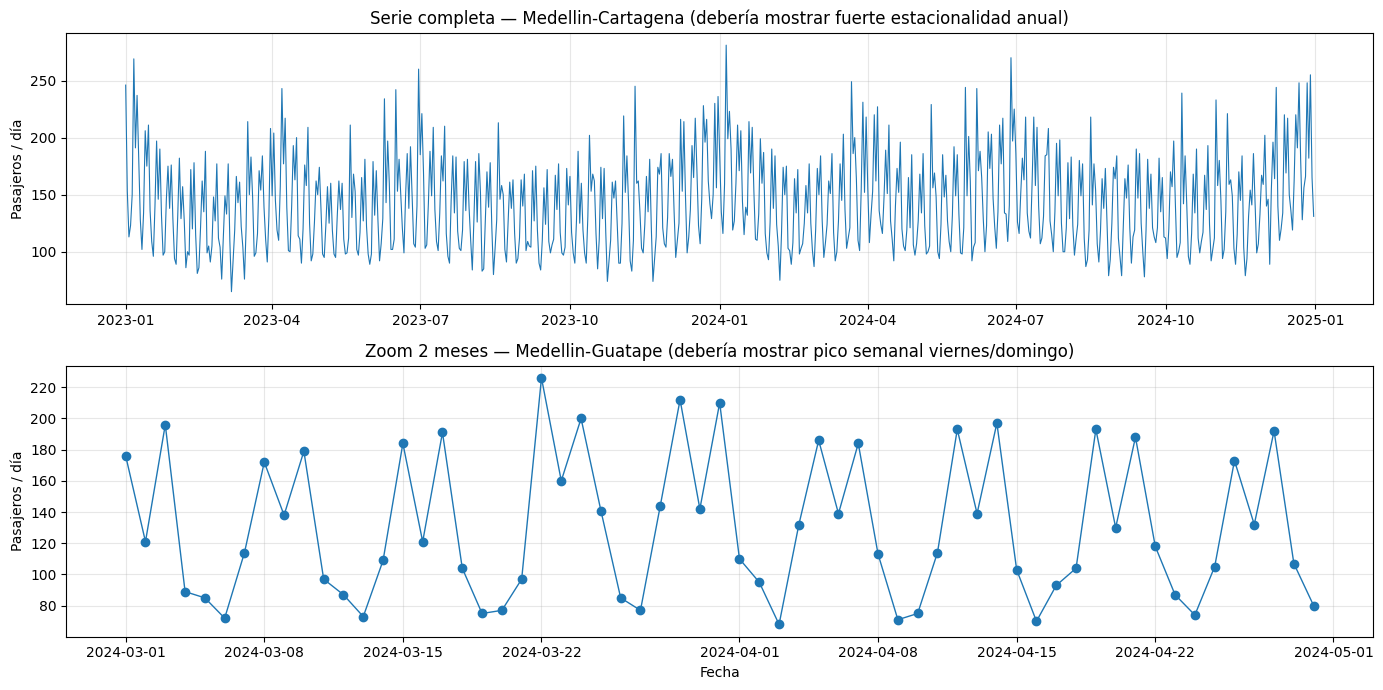

In [12]:
# Visualización: 1 ruta completa para verificar los patrones a ojo
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Panel 1: serie completa de Medellin-Cartagena (ruta más estacional)
ruta_focus = 'Medellin-Cartagena'
df_focus = df[df['ruta'] == ruta_focus].copy()
axes[0].plot(df_focus['fecha'], df_focus['pasajeros'], linewidth=0.8)
axes[0].set_title(f'Serie completa — {ruta_focus} (debería mostrar fuerte estacionalidad anual)')
axes[0].set_ylabel('Pasajeros / día')
axes[0].grid(alpha=0.3)

# Panel 2: zoom 2 meses de Medellin-Guatape para ver el patrón semanal
ruta_focus_2 = 'Medellin-Guatape'
df_focus_2 = df[(df['ruta'] == ruta_focus_2) &
                (df['fecha'] >= '2024-03-01') &
                (df['fecha'] <= '2024-04-30')].copy()
axes[1].plot(df_focus_2['fecha'], df_focus_2['pasajeros'], marker='o', linewidth=1)
axes[1].set_title(f'Zoom 2 meses — {ruta_focus_2} (debería mostrar pico semanal viernes/domingo)')
axes[1].set_ylabel('Pasajeros / día')
axes[1].set_xlabel('Fecha')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Guardado del dataset

Guardamos el dataset en formato CSV directamente en la carpeta `data/` del proyecto en Drive.


In [13]:
# Ruta de salida: carpeta data/ del proyecto en Drive
RUTA_SALIDA = f'{DRIVE}/data/rutaviva_demanda.csv'

df.to_csv(RUTA_SALIDA, index=False, encoding='utf-8')
print(f'Dataset guardado en: {RUTA_SALIDA}')
print(f'Tamaño: {len(df)} filas × {len(df.columns)} columnas')

# Verificación: recarga y muestra primeras filas
df_check = pd.read_csv(RUTA_SALIDA, parse_dates=['fecha'])
print('\nVerificación de la recarga:')
df_check.head()

Dataset guardado en: /content/drive/MyDrive/proyecto3-rutaviva/data/rutaviva_demanda.csv
Tamaño: 4386 filas × 3 columnas

Verificación de la recarga:


,fecha,ruta,pasajeros
0,2023-01-01,Medellin-Pereira,327
1,2023-01-02,Medellin-Pereira,183
2,2023-01-03,Medellin-Pereira,154
3,2023-01-04,Medellin-Pereira,166
4,2023-01-05,Medellin-Pereira,181


## 9. Síntesis

Hemos generado un dataset sintético de **4 386 observaciones** (2 años × 6 rutas × 731 días — bueno, casi: 2×365 + 1 día bisiesto en 2024) con las siguientes propiedades:

- ✅ **Tendencia** lineal positiva (~5%/año).
- ✅ **Estacionalidad semanal** marcada (picos viernes/domingo).
- ✅ **Estacionalidad anual** (temporada alta dic-ene, Semana Santa, mitad de año).
- ✅ **Efecto de festivos** colombianos (puentes y festivos simples).
- ✅ **Ruido gaussiano** proporcional al nivel base de cada ruta.

El dataset está listo para el siguiente paso: el **EDA del módulo 1**, en el notebook `01_eda_modulo1.ipynb`.

---

**Decisiones de diseño justificadas:**

| Decisión | Justificación |
|---|---|
| Granularidad diaria | Alineada con el objetivo del enunciado: predicción a 30 días. |
| Periodo de 2 años | Necesario para que un LSTM capture al menos 2 ciclos anuales completos. |
| 6 rutas con perfiles diferenciados | Permite que el modelo aprenda comportamientos heterogéneos y enriquece el análisis. |
| Modelo multiplicativo | Refleja la interacción real entre estacionalidades (un viernes en temporada alta no es la suma de los dos efectos, sino su producto). |
| Semilla fija (42) | Reproducibilidad: cualquier persona que ejecute el notebook obtiene el mismo dataset. |
